In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('../precio_consumidor_2008-2026.csv')

In [5]:
display(df.head())
print("Dimensiones:", df.shape)
df.info()

,Anio,Mes,Semana,Fecha inicio,Fecha termino,ID region,Region,Sector,Tipo de punto monitoreo,Grupo,Producto,Unidad,Precio minimo,Precio maximo,Precio promedio
0,2008,3,12,2008-03-17,2008-03-21,13,Región Metropolitana de Santiago,Norte,Feria libre,Frutas,Limón|Sin especificar|1a plateado,$/kilo,NaN,NaN,"1000,000000"
1,2008,3,12,2008-03-17,2008-03-21,13,Región Metropolitana de Santiago,Norte,Feria libre,Frutas,Manzana|Fuji|Primera,$/kilo,NaN,NaN,"400,000000"
2,2008,3,12,2008-03-17,2008-03-21,13,Región Metropolitana de Santiago,Norte,Feria libre,Frutas,Manzana|Granny Smith|Primera,$/kilo,NaN,NaN,"350,000000"
3,2008,3,12,2008-03-17,2008-03-21,13,Región Metropolitana de Santiago,Norte,Feria libre,Frutas,Naranja|Navel Late|Primera,$/kilo,NaN,NaN,"400,000000"
4,2008,3,12,2008-03-17,2008-03-21,13,Región Metropolitana de Santiago,Norte,Feria libre,Frutas,Palta|Hass|Primera,$/kilo,NaN,NaN,"1200,000000"


Dimensiones: (3962152, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3962152 entries, 0 to 3962151
Data columns (total 15 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   Anio                     int64  
 1   Mes                      int64  
 2   Semana                   int64  
 3   Fecha inicio             object 
 4   Fecha termino            object 
 5   ID region                int64  
 6   Region                   object 
 7   Sector                   object 
 8   Tipo de punto monitoreo  object 
 9   Grupo                    object 
 10  Producto                 object 
 11  Unidad                   object 
 12  Precio minimo            float64
 13  Precio maximo            float64
 14  Precio promedio          object 
dtypes: float64(2), int64(4), object(9)
memory usage: 453.4+ MB


¿Cuáles son los productos cuyos precios reaccionan más rápido a los cambios en el IPC mensual? -> Entender cómo el cambio en el costo de la vida general afecta a productos específicos.

¿Existe una brecha de precios significativa entre las ferias libres y los supermercados para la misma canasta de productos a lo largo de los años? -> Segmentación de mercado.

¿Qué eventos históricos provocaron desviaciones atípicas en los precios sin ser percibidas inmediatamente por el IPC general? -> Identificar comportamientos fuera de lo común justificados por distintos eventos históricos (crisis económicas, eventos climáticos o sociales, etc.).

In [6]:
df.isna().sum()

Anio                           0
Mes                            0
Semana                         0
Fecha inicio                   0
Fecha termino                  0
ID region                      0
Region                         0
Sector                         0
Tipo de punto monitoreo        0
Grupo                          0
Producto                       0
Unidad                         0
Precio minimo              71989
Precio maximo              71989
Precio promedio                0
dtype: int64

Los datos faltantes corresponden a precio mínimo y máximo entre los años 2008 y 2012, pues allí solo se estipulaba el precio promedio. Dejaré esos datos puesto que, a pesar de no tener esos valores, está el promedio y sobre ese valor se pueden hacer análisis igualmente.

In [7]:
print("Total de filas duplicadas:", df.duplicated().sum())

Total de filas duplicadas: 0


In [8]:
df.describe()

,Anio,Mes,Semana,ID region,Precio minimo,Precio maximo
count,3.962152e+06,3.962152e+06,3.962152e+06,3.962152e+06,3.890163e+06,3.890163e+06
mean,2.019708e+03,6.418379e+00,2.619325e+01,9.213173e+00,3.080920e+03,3.695617e+03
std,3.688839e+00,3.499931e+00,1.526428e+01,3.516901e+00,3.339025e+03,3.919909e+03
min,2.008000e+03,1.000000e+00,1.000000e+00,4.000000e+00,0.000000e+00,0.000000e+00
25%,2.017000e+03,3.000000e+00,1.300000e+01,7.000000e+00,8.190000e+02,1.000000e+03
50%,2.020000e+03,6.000000e+00,2.600000e+01,9.000000e+00,1.690000e+03,2.000000e+03
75%,2.023000e+03,1.000000e+01,4.000000e+01,1.300000e+01,4.590000e+03,5.499000e+03
max,2.026000e+03,1.200000e+01,5.300000e+01,1.600000e+01,5.000000e+04,1.415560e+05


In [9]:
df['Precio promedio'] = pd.to_numeric(df['Precio promedio'].str.replace(',', '.'), errors='coerce')
print(df['Precio promedio'].dtype)

float64


In [10]:

df['Fecha_Mes'] = pd.to_datetime(df['Anio'].astype(str) + '-' + df['Mes'].astype(str) + '-01')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3962152 entries, 0 to 3962151
Data columns (total 16 columns):
 #   Column                   Dtype         
---  ------                   -----         
 0   Anio                     int64         
 1   Mes                      int64         
 2   Semana                   int64         
 3   Fecha inicio             object        
 4   Fecha termino            object        
 5   ID region                int64         
 6   Region                   object        
 7   Sector                   object        
 8   Tipo de punto monitoreo  object        
 9   Grupo                    object        
 10  Producto                 object        
 11  Unidad                   object        
 12  Precio minimo            float64       
 13  Precio maximo            float64       
 14  Precio promedio          float64       
 15  Fecha_Mes                datetime64[ns]
dtypes: datetime64[ns](1), float64(3), int64(4), object(8)
memory usage: 483.

Se generó esta nueva columna para hacer más simple la unión entre el valor del IPC (que es mensual) con la tabla de precio_consumidor.

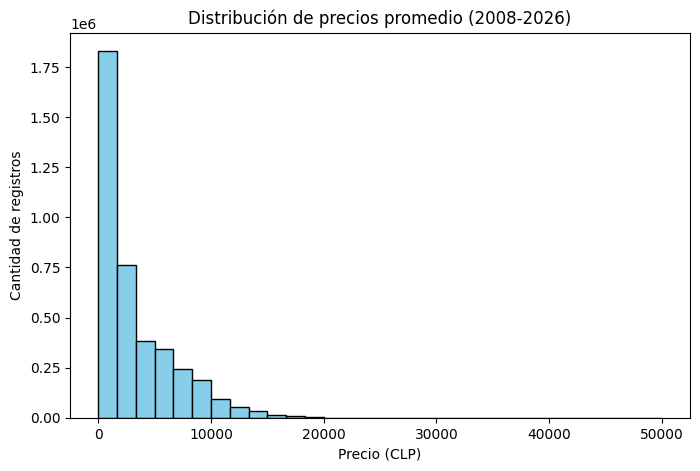

In [12]:
plt.figure(figsize=(8, 5))
df['Precio promedio'].plot(kind='hist', bins=30, color='skyblue', edgecolor='black')
plt.title('Distribución de precios promedio (2008-2026)')
plt.xlabel('Precio (CLP)')
plt.ylabel('Cantidad de registros')
plt.show()

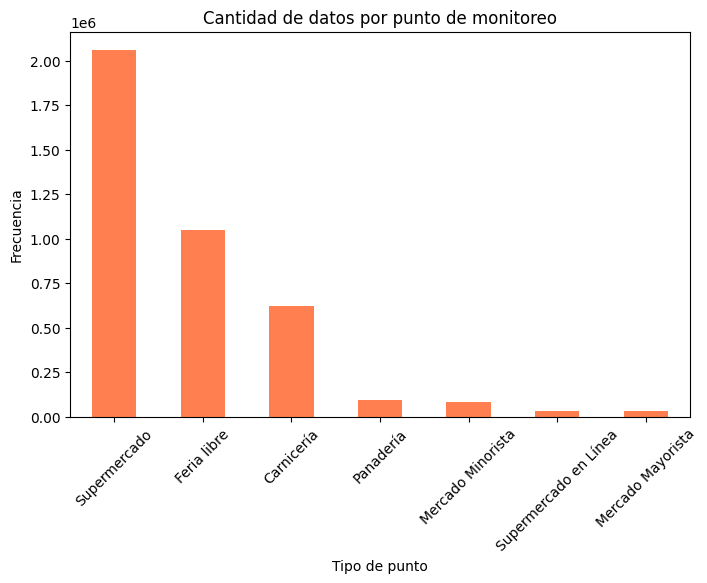

In [13]:
plt.figure(figsize=(8, 5))
df['Tipo de punto monitoreo'].value_counts().plot(kind='bar', color='coral')
plt.title('Cantidad de datos por punto de monitoreo')
plt.xlabel('Tipo de punto')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.show()